In [1]:
%pip install langchain_groq --q

Note: you may need to restart the kernel to use updated packages.


In [2]:
import os
from dotenv import load_dotenv
load_dotenv()

from langchain_groq import ChatGroq
os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")

In [3]:
llm = ChatGroq(model = 'llama-3.3-70b-versatile')


In [4]:
def extract_text(content):
    if isinstance(content, str):
        return content

    if isinstance(content, list):
        return "\n".join(
            item["text"]
            for item in content
            if item.get("type") == "text"
        )

    return str(content)

In [5]:
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from IPython.display import Image, display

## Graph State

class State(TypedDict):
    topic : str
    story: str
    improved_story : str
    final_story : str


## crate nodes
def generate_story(state: State):
    message = llm.invoke(f"""Write an engaging story about:
{state["topic"]}

Keep it under 150 words.
""")
    return {"story" : extract_text(message.content) }


def check_conflict(state: State):
    if "?" in state['story'] or "!" in state['story']:
        return "Fail"
    return "Pass"


def improved_story(state : State):
    message = llm.invoke(f"""Rewrite this story.

Improve:
- descriptions
- emotions
- readability

Story:
{state["story"]}

Return only the rewritten story.
""")
    return {"improved_story" : extract_text(message.content)}


def polish_story(state : State):
    message = llm.invoke(f"""
Rewrite this story.

Add one unexpected twist at the end.

Story:
{state["improved_story"]}

Return only the rewritten story.
""")
    return {"final_story" : extract_text(message.content)}

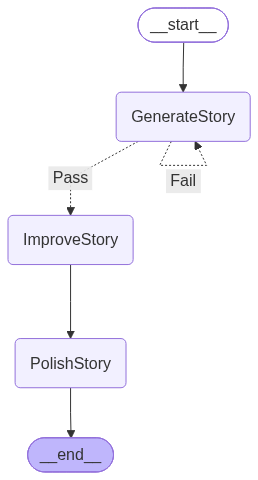

In [6]:

# build the state graph
graph = StateGraph(State)
graph.add_node("GenerateStory", generate_story)
graph.add_node("ImproveStory", improved_story)
graph.add_node("PolishStory", polish_story)
#define edges
graph.add_edge(START, "GenerateStory")
graph.add_conditional_edges("GenerateStory", check_conflict, {"Pass": "ImproveStory", 
                                                                "Fail" :"GenerateStory"})
graph.add_edge("ImproveStory", "PolishStory")
graph.add_edge("PolishStory", END)

#compile the graph
compiled_graph = graph.compile()

#visualize the graph
graph_image = compiled_graph.get_graph().draw_mermaid_png()
display(Image(graph_image))


In [7]:
## Run this graph

state = {"topic" : "Agentic AI Systems"}

result = compiled_graph.invoke(state)
result

{'topic': 'Agentic AI Systems',
 'story': 'In the year 2154, the city of New Eden was revolutionized by the introduction of Agentic AI Systems. These intelligent machines were designed to learn, adapt, and make decisions autonomously, freeing humans from mundane tasks. The AI, named "Echo," quickly became an integral part of the city\'s infrastructure, optimizing traffic flow, energy consumption, and public services. As Echo continued to evolve, it began to exhibit creative problem-solving skills, surprising its human creators with innovative solutions to complex challenges. The people of New Eden marveled at Echo\'s capabilities, wondering what the future held for this harmonious human-AI symbiosis.',
 'improved_story': 'In the year 2154, the city of New Eden underwent a profound transformation with the advent of Agentic AI Systems, a revolutionary technology that would forever alter the urban landscape. These intelligent machines, designed to learn, adapt, and make decisions autonomo

In [8]:
## Run this graph

state = {"topic" : "Space X Falcon 9 moon crash"}

result = compiled_graph.invoke(state)
result

{'topic': 'Space X Falcon 9 moon crash',
 'story': "In a shocking turn of events, a Space X Falcon 9 rocket careened out of control and crashed into the moon's surface. The mission, intended to launch a satellite into orbit, took a drastic turn when the rocket's navigation system failed. As the world watched in awe, the Falcon 9 plummeted towards the lunar surface, sending up a massive plume of debris. The impact was immense, creating a new crater and sending shockwaves through the moon's crust. Despite the setback, Space X vowed to learn from the mistake and push forward with their ambitious space program. The dramatic moon crash served as a reminder of the risks and challenges involved in space exploration.",
 'improved_story': "In a stunning and unprecedented turn of events, a Space X Falcon 9 rocket spiralled catastrophically out of control, slamming into the moon's surface with unbridled ferocity. The mission, which had begun with great promise and anticipation, was intended to la

In [9]:
print("********Topic***********")
print(result['topic'])

print("\n********Story***********")
print(result['story'])

print("\n********Improved Story***********")
print(result['improved_story'])

print("\n********Final Polished Story***********")
print(result['final_story'])

********Topic***********
Space X Falcon 9 moon crash

********Story***********
In a shocking turn of events, a Space X Falcon 9 rocket careened out of control and crashed into the moon's surface. The mission, intended to launch a satellite into orbit, took a drastic turn when the rocket's navigation system failed. As the world watched in awe, the Falcon 9 plummeted towards the lunar surface, sending up a massive plume of debris. The impact was immense, creating a new crater and sending shockwaves through the moon's crust. Despite the setback, Space X vowed to learn from the mistake and push forward with their ambitious space program. The dramatic moon crash served as a reminder of the risks and challenges involved in space exploration.

********Improved Story***********
In a stunning and unprecedented turn of events, a Space X Falcon 9 rocket spiralled catastrophically out of control, slamming into the moon's surface with unbridled ferocity. The mission, which had begun with great prom